Saving heart_disease_uci.csv to heart_disease_uci (5).csv
Decision Tree Accuracy: 0.7833333333333333
Random Forest Accuracy: 0.8666666666666667

Decision Tree Classification Report

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        35
           1       0.75      0.72      0.73        25

    accuracy                           0.78        60
   macro avg       0.78      0.77      0.78        60
weighted avg       0.78      0.78      0.78        60


Random Forest Classification Report

              precision    recall  f1-score   support

           0       0.86      0.91      0.89        35
           1       0.87      0.80      0.83        25

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



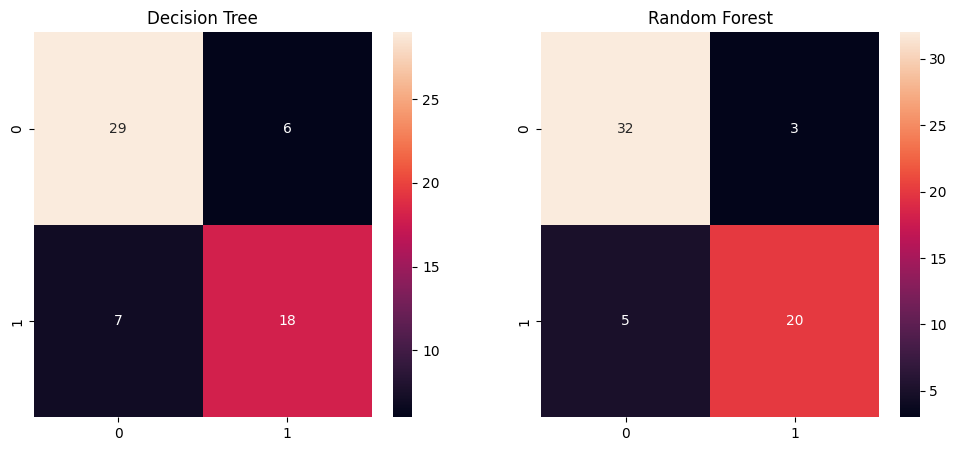

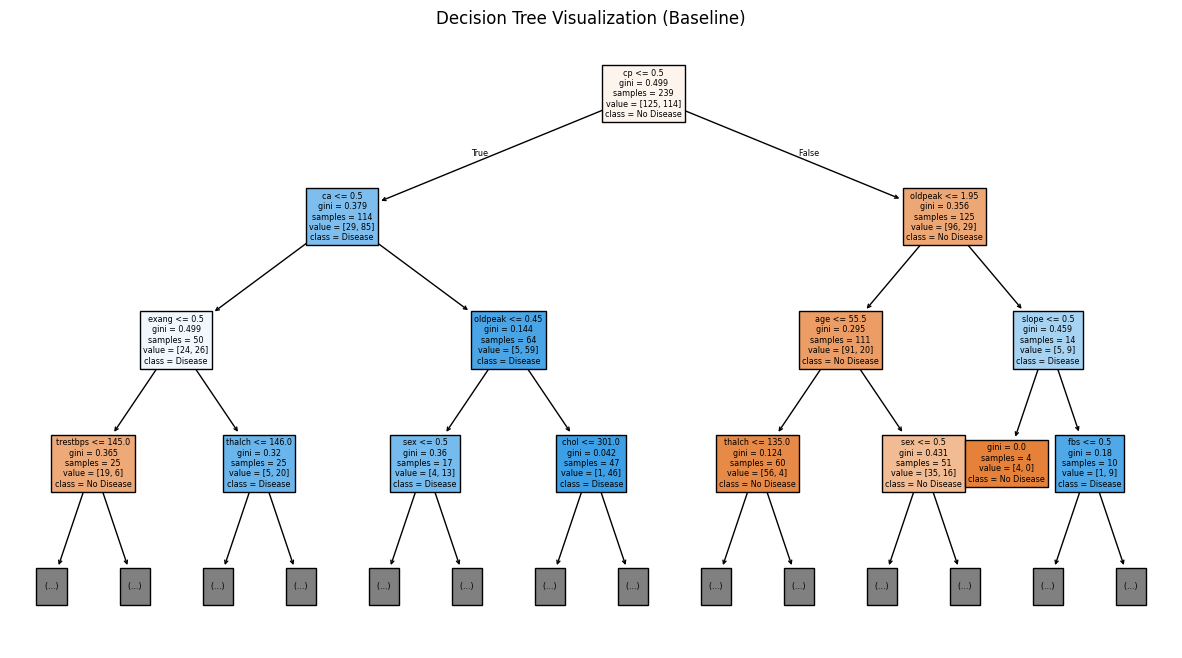

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

df = df.dropna()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype("category").cat.codes

X = df.drop("num", axis=1)
y = df["num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nDecision Tree Classification Report\n")
print(classification_report(y_test, dt_pred))

print("\nRandom Forest Classification Report\n")
print(classification_report(y_test, rf_pred))

cm_dt = confusion_matrix(y_test, dt_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm_dt, annot=True, fmt="d")
plt.title("Decision Tree")

plt.subplot(1,2,2)
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Random Forest")

plt.show()

plt.figure(figsize=(15,8))
plot_tree(dt, feature_names=X.columns, class_names=["No Disease","Disease"], filled=True, max_depth=3)
plt.title("Decision Tree Visualization (Baseline)")
plt.show()

Saving heart_disease_uci.csv to heart_disease_uci (8).csv
Best DT Params: {'max_depth': 7, 'min_samples_split': 2}
Best RF Params: {'max_depth': 3, 'n_estimators': 100}
Decision Tree Accuracy: 0.7833333333333333
Random Forest Accuracy: 0.8666666666666667

Decision Tree Classification Report

              precision    recall  f1-score   support

           0       0.75      0.94      0.84        35
           1       0.88      0.56      0.68        25

    accuracy                           0.78        60
   macro avg       0.81      0.75      0.76        60
weighted avg       0.80      0.78      0.77        60


Random Forest Classification Report

              precision    recall  f1-score   support

           0       0.86      0.91      0.89        35
           1       0.87      0.80      0.83        25

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



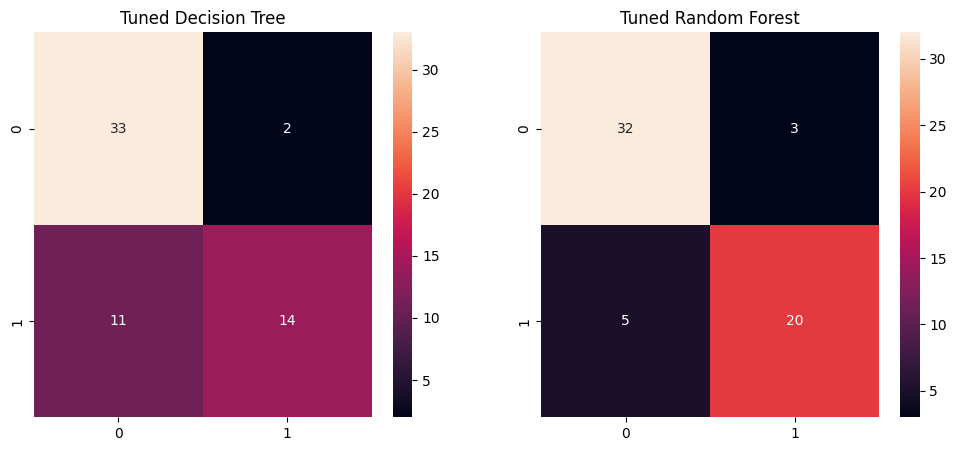

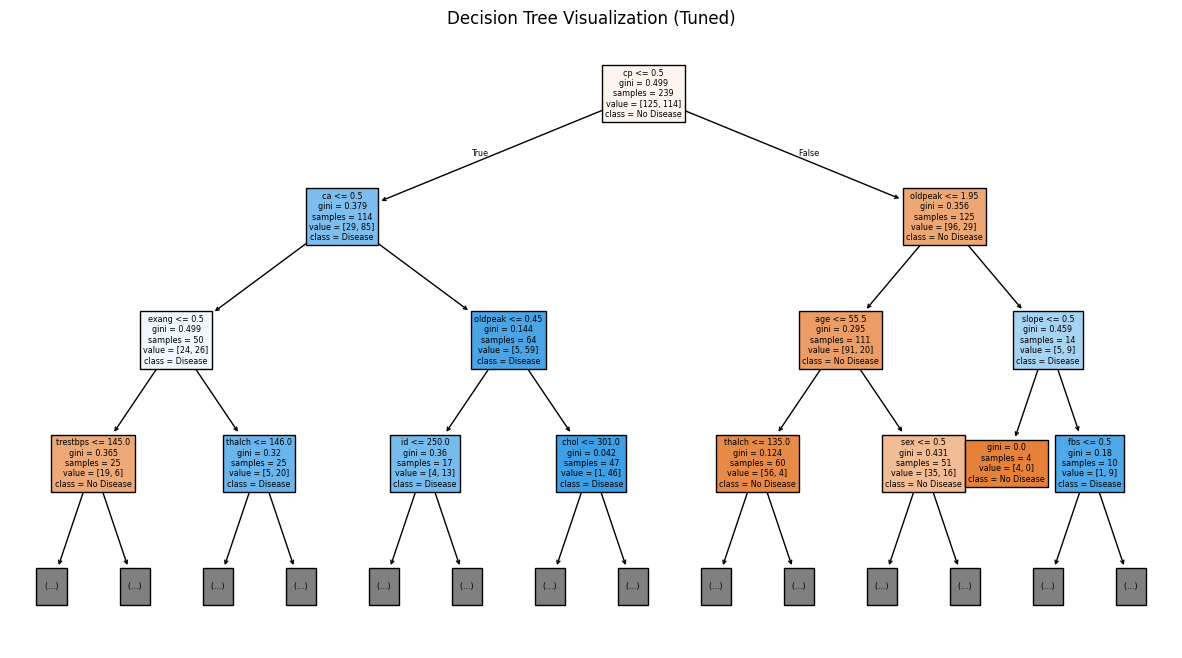

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

df = df.dropna()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype("category").cat.codes

X = df.drop("num", axis=1)
y = df["num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_params = {"max_depth": [3,5,7,None], "min_samples_split": [2,5,10]}
rf_params = {"n_estimators": [50,100,150], "max_depth": [3,5,7,None]}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5)
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)

dt_grid.fit(X_train, y_train)
rf_grid.fit(X_train, y_train)

dt_best = dt_grid.best_estimator_
rf_best = rf_grid.best_estimator_

dt_pred = dt_best.predict(X_test)
rf_pred = rf_best.predict(X_test)

print("Best DT Params:", dt_grid.best_params_)
print("Best RF Params:", rf_grid.best_params_)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nDecision Tree Classification Report\n")
print(classification_report(y_test, dt_pred))

print("\nRandom Forest Classification Report\n")
print(classification_report(y_test, rf_pred))

cm_dt = confusion_matrix(y_test, dt_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm_dt, annot=True, fmt="d")
plt.title("Tuned Decision Tree")

plt.subplot(1,2,2)
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Tuned Random Forest")

plt.show()

plt.figure(figsize=(15,8))
plot_tree(dt_best, feature_names=X.columns, class_names=["No Disease","Disease"], filled=True, max_depth=3)
plt.title("Decision Tree Visualization (Tuned)")
plt.show()